# Galakser Utforsker
Dette er en kladd for å teste klynging av ord-koordinasjoner direkte i en Notebook.

In [1]:
import network_explorer as ne
import json
import os
# Koble til databasen
db_path = 'koordinasjoner.db'
exp = ne.NetworkExplorer(db_path)

## Hent Nettverk og Linjegraf-klynger
Her kan vi teste søk. Funksjonen `get_neighborhood` tar inn `max_depth` (nivå) som bestemmer hvor mange ledd ut den skal lete. For eksempel `max_depth=2` eller `max_depth=3`.

In [2]:
%%time
# Parametere for søket
def neighbours_roaring(ord_x = 'is',
    tabell = 'avis_og', # prøv også 'avis_eller', 'bok_nob_og'
    nivaa = 2,          # Dybde (1 = bare direkte naboer, 2 = naboers naboer)
    topp_n = 50,        # Hvilken Bitmap vi skal bruke
    sample_k = None,    # Evt ned-sampling
    seed = None):       # Seed for reproduserbarhet
    
    # Kjør BFS søket i SQLite
        nodes, edges = exp.get_neighborhood_roaring(ord_x, tabell, max_depth=nivaa, top_n=topp_n, sample_k=sample_k, seed=seed)
    
        # Kjør linjegraf-klynging på resultatet (dette pakker nodene inn i dictionaries med overlappende 'groups')
        graf_data_bm = exp.get_clustered_json_dict(nodes, edges)
        print(f"Fant {len(graf_data_bm['nodes'])} ord og {len(graf_data_bm['links'])} forbindelser.")
        return graf_data_bm

CPU times: user 2 μs, sys: 0 ns, total: 2 μs
Wall time: 2.86 μs


In [3]:
#graf_data_bm['nodes']

## Visualisering
Dataene ligger nå perfekte for bruk med for eksempel `pyvis` for å tegne grafen interaktivt her inne i notebooken.

In [4]:
import matplotlib
import networkx as nx
import matplotlib.pyplot as plt

In [5]:
def draw(graf_data_bm):
    G = nx.Graph()
    
    # Legg til nodene
    for n in graf_data_bm['nodes']:
        # SIKRING: Hvis groups allerede er en liste/tuple, gjør vi den om til en sortert streng.
        # Hvis det er en vanlig streng/int fra før, fungerer det likevel.
        if isinstance(n['groups'], (list, tuple, set)):
            gruppe_id = " + ".join(sorted([str(g) for g in n['groups']]))
        else:
            gruppe_id = str(n['groups'])
            
        G.add_node(n['id'], label=n['label'], groups=gruppe_id)
    
    # Legg til kantene
    for e in graf_data_bm['links']:
        G.add_edge(e['source'], e['target'], weight=e['ratio'])
    
    # --- GENERER UNIKE FARGER FOR KOMBINASJONENE ---
    unike_kombinasjoner = sorted(list(set(nx.get_node_attributes(G, 'groups').values())))
    
    # Bruker oppdatert Matplotlib-syntaks (matplotlib.colormaps) for å unngå advarsler
    cmap = plt.colormaps['tab20'].resampled(len(unike_kombinasjoner))
    gruppe_til_farge = {gruppe: cmap(i) for i, gruppe in enumerate(unike_kombinasjoner)}
    
    # Lag fargelisten i riktig node-rekkefølge
    node_farger = [gruppe_til_farge[G.nodes[n]['groups']] for n in G.nodes]
    
    # Tegn grafen
    plt.figure(figsize=(12, 12))
    pos = nx.spring_layout(G, k=0.6, iterations=50)
    
    nx.draw(
        G, 
        pos=pos, 
        with_labels=True, 
        node_color=node_farger, 
        font_size=10, 
        node_size=500
    )
    
    plt.show()


In [6]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict

def show_clusters(graf_data_bm):
    G = nx.Graph()
    
    # Legg til nodene og håndter flere grupper
    for n in graf_data_bm['nodes']:
        if isinstance(n['groups'], (list, tuple, set)):
            gruppe_id = " + ".join(sorted([str(g) for g in n['groups']]))
        else:
            gruppe_id = str(n['groups'])
            
        G.add_node(n['id'], label=n['label'], groups=gruppe_id)
    
    # Legg til kantene
    for e in graf_data_bm['links']:
        G.add_edge(e['source'], e['target'], weight=e['ratio'])
    
    # --- 1. GRUPPER NODENE FOR UTSKRIFT (CLUSTERE) ---
    clustere = defaultdict(list)
    for n_id, data in G.nodes(data=True):
        # Bruker labelen hvis den finnes, ellers ID-en til noden
        navn = data.get('label', n_id)
        clustere[data['groups']].append(navn)
    
    # Skriv ut clustrene i terminalen
    print("=== OVERSIKT OVER CLUSTERE ===")
    for gruppe, noder in sorted(clustere.items()):
        print(f"\nKlynge: [{gruppe}] ({len(noder)} noder)")
        print(f"  -> {', '.join(noder)}")
    print("\n" + "="*30)
    



In [34]:
%%time
graf_data_bm = neighbours_roaring(ord_x="isil", nivaa=3, topp_n=15, sample_k=None, seed=None)

Fant 130 ord og 187 forbindelser.
CPU times: user 13.4 ms, sys: 11.7 ms, total: 25.1 ms
Wall time: 55 ms


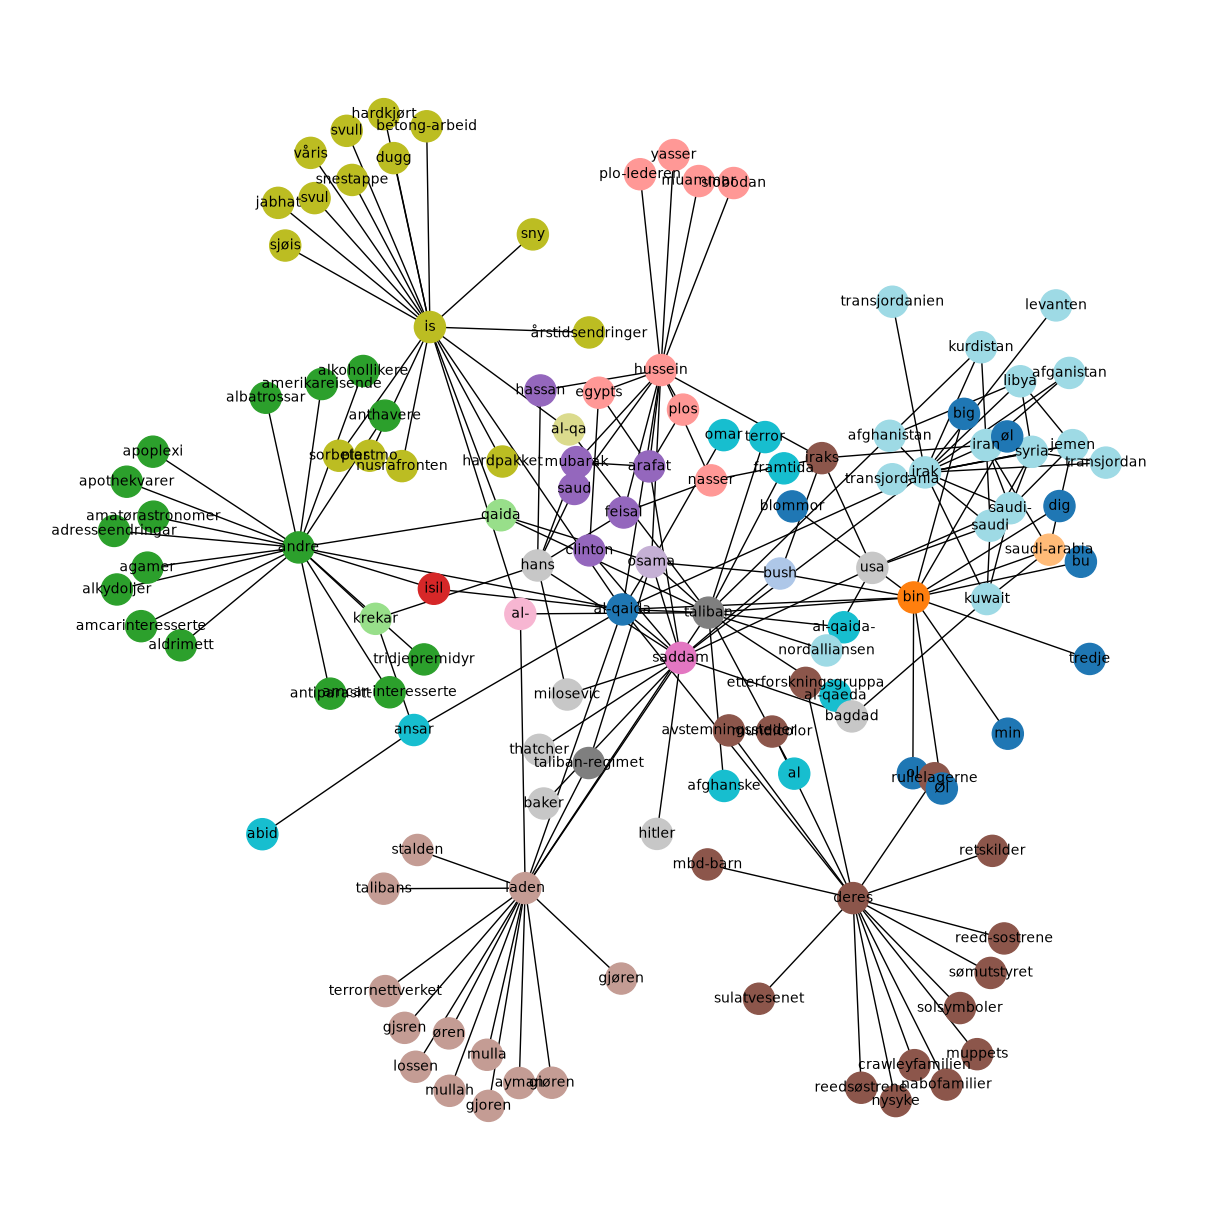

In [35]:
draw(graf_data_bm)

In [36]:
group_ids = {group for node in graf_data_bm['nodes'] for group in node['groups']}

for group_id in group_ids:
    labels = [x['label'] for x in graf_data_bm['nodes'] if group_id in x['groups']]
    print(group_id, " ==== ")
    print(', '.join(labels), '\n')
              

0  ==== 
al-qaida, big, bin, blommor, bu, bush, dig, min, ol, saudi-arabia, tredje, Øl, øl 

1  ==== 
adresseendringar, agamer, al-qaida, albatrossar, aldrimett, alkohollikere, alkydoljer, amatørastronomer, amcar-interesserte, amcarinteresserte, amerikareisende, andre, anthavere, antiparasitt, apoplexi, apothekvarer, isil, krekar, qaida, tridjepremidyr 

2  ==== 
al-qaida, arafat, bush, clinton, egypts, feisal, hassan, hussein, iraks, muammar, mubarak, nasser, osama, plo-lederen, plos, saud, slobodan, yasser 

3  ==== 
al-qaida, avstemningssteder, crawleyfamilien, deres, etterforskningsgruppa, mbd-barn, mundicolor, muppets, nabofamilier, nysyke, reed-sostrene, reedsøstrene, retskilder, rullelagerne, solsymboler, sulatvesenet, sømutstyret 

4  ==== 
al-, al-qaida, ayman, giøren, gjoren, gjsren, gjøren, laden, lossen, mulla, mullah, saddam, stalden, taliban, taliban-regimet, talibans, terrornettverket, øren 

5  ==== 
al-qaida, arafat, bagdad, baker, bush, clinton, feisal, hans, hassan, 